In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/layoffs.csv")
df.shape

(4540, 11)

In [3]:
df.head()

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
0,Chime,SF Bay Area,150.0,7/31/2026,0.10,Finance,https://www.bankingdive.com/news/chime-cut-wor...,Series G,2300.0,United States,7/31/2026
1,Lightspeed Commerce,"Montreal, Non-U.S.",100.0,7/31/2026,0.03,Retail,https://betakit.com/lightspeed-narrows-net-los...,Post-IPO,1200.0,Canada,7/31/2026
2,GoLemon,"Lagos, Non-U.S.",33.0,7/30/2026,1.00,Retail,https://nairametrics.com/2026/07/30/nigerian-s...,Unknown,NaN,Nigeria,7/30/2026
3,Krutrim,"Bengaluru, Non-U.S.",20.0,7/28/2026,0.50,AI,https://yourstory.com/2026/07/krutrim-lays-off...,Unknown,304.0,India,7/29/2026
4,Luno,"London, Non-U.S.",NaN,7/28/2026,0.20,Crypto,https://www.bloomberg.com/news/articles/2026-0...,Acquired,13.0,United Kingdom,7/29/2026


In [4]:
df.dtypes

company                    str
location                   str
total_laid_off         float64
date                       str
percentage_laid_off    float64
industry                   str
source                     str
stage                      str
funds_raised           float64
country                    str
date_added                 str
dtype: object

In [5]:
df['date'] = pd.to_datetime(df['date'],errors='coerce')
df['date_added'] = pd.to_datetime(df['date_added'],errors='coerce')

df[['date','date_added']].dtypes

date          datetime64[us]
date_added    datetime64[us]
dtype: object

In [6]:
df.isnull().sum()

company                   0
location                  1
total_laid_off         1570
date                      0
percentage_laid_off    1693
industry                  2
source                    3
stage                     8
funds_raised            537
country                   2
date_added                0
dtype: int64

In [7]:
df['year'] = df['date'].dt.year
df['quarter'] = df['date'].dt.quarter
print(df[['year','quarter']])

      year  quarter
0     2026        3
1     2026        3
2     2026        3
3     2026        3
4     2026        3
...    ...      ...
4535  2020        1
4536  2020        1
4537  2020        1
4538  2020        1
4539  2020        1

[4540 rows x 2 columns]


In [8]:
print(df['date'].min())
print(df['date'].max())

2020-03-11 00:00:00
2026-07-31 00:00:00


In [9]:
df['disclosed'] = df['total_laid_off'].notnull()
df[['total_laid_off','disclosed']].head()

,total_laid_off,disclosed
0,150.0,True
1,100.0,True
2,33.0,True
3,20.0,True
4,NaN,False


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['industry'].unique()

<StringArray>
[       'Finance',         'Retail',             'AI',         'Crypto',
        'Support',          'Media',       'Hardware',       'Consumer',
          'Other',        'Product', 'Transportation',      'Marketing',
       'Security',           'Data',         'Travel',          'Legal',
      'Education',     'Healthcare',             'HR',     'Recruiting',
    'Real Estate',           'Food',          'Sales',  'Manufacturing',
      'Logistics', 'Infrastructure',        'Fitness',         'Energy',
              nan,      'Aerospace',   'Construction']
Length: 31, dtype: str

In [12]:
df['stage'].unique()

<StringArray>
[      'Series G',       'Post-IPO',        'Unknown',       'Acquired',
       'Series B',       'Series C',       'Series F',           'Seed',
       'Series D',       'Series E', 'Private Equity',       'Series A',
     'Subsidiary',              nan,       'Series H',       'Series J',
       'Series I']
Length: 17, dtype: str

In [13]:
# clean location column: remove ", Non-U.S." suffix so cities aren't split across two labels
df['location'] = df['location'].str.replace(', Non-U.S.','',regex=False)

In [14]:
df[['total_laid_off','percentage_laid_off','funds_raised']].describe()

,total_laid_off,percentage_laid_off,funds_raised
count,2970.000000,2847.000000,4003.000000
mean,312.395960,0.293536,876.172894
std,1121.101489,0.303975,4558.559896
min,3.000000,0.000000,0.700000
25%,40.000000,0.100000,55.000000
50%,90.000000,0.170000,175.000000
75%,200.000000,0.330000,484.000000
max,22000.000000,1.000000,121900.000000


In [15]:
# count layoff events per year
df.groupby('year')['company'].count()

year
2020     635
2021      44
2022    1231
2023    1390
2024     633
2025     333
2026     274
Name: company, dtype: int64

In [16]:
# total people laid off per year
df.groupby('year')['total_laid_off'].sum()

year
2020     80998.0
2021     15823.0
2022    165269.0
2023    265660.0
2024    152922.0
2025    122606.0
2026    124538.0
Name: total_laid_off, dtype: float64

In [17]:
# average people laid off per event, by year
df.groupby('year')['total_laid_off'].mean()

year
2020    170.522105
2021    510.419355
2022    201.302071
2023    312.909305
2024    394.128866
2025    540.114537
2026    695.743017
Name: total_laid_off, dtype: float64

CONFIRMED: average people laid off per event (2022-2026): 201 -> 313 -> 394 -> 540 -> 696
- Steady, consistent rise across 5 years (2021 excluded - too few events, unreliable average)
- Layoff events are less frequent since 2023 peak, but each event has gotten progressively bigger - avg event size more than tripled since 2022
CONFIRMED HEADLINE INSIGHT: "Tech layoffs are becoming rarer but more severe" - companies are consolidating cuts into fewer, larger rounds rather than frequent small ones

Syntax of .agg()

df.groupby('grouping_column').agg(
    new_column_name=('column_to_use', 'operation_name')
)

In [18]:
# combine event count and average layoff size into one table, grouped by year
yearly = df.groupby('year').agg(
    event_count = ('company','count'),
    avg_size = ('total_laid_off','mean')
)
yearly

,event_count,avg_size
year,,
2020,635,170.522105
2021,44,510.419355
2022,1231,201.302071
2023,1390,312.909305
2024,633,394.128866
2025,333,540.114537
2026,274,695.743017


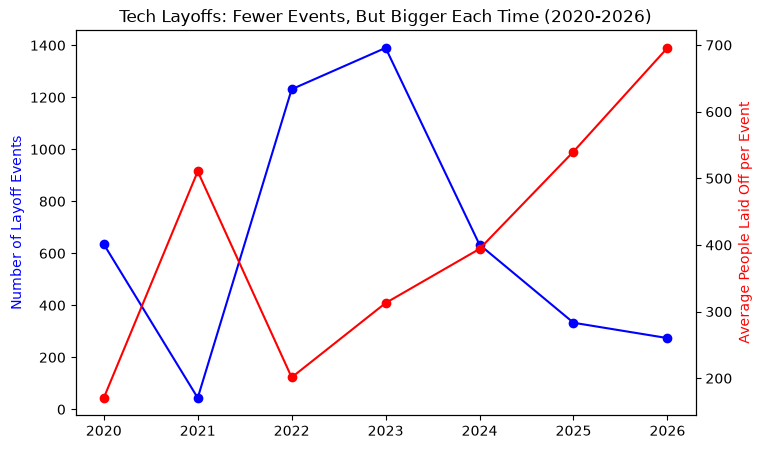

In [19]:
# create the chart canvas and first axis
fig,ax1 = plt.subplots(figsize=(8,5))

# plot event count on the left y-axis
ax1.plot(yearly.index,yearly['event_count'],color='blue',marker='o',label='Event Count')
ax1.set_ylabel('Number of Layoff Events',color='blue')

# add a second y-axis sharing the same x-axis, plot avg_size on it
ax2 = ax1.twinx()
ax2.plot(yearly.index,yearly['avg_size'],color='red',marker='o',label='Avg Size per Event')
ax2.set_ylabel('Average People Laid Off per Event',color='red')

# add title and display the chart
plt.title('Tech Layoffs: Fewer Events, But Bigger Each Time (2020-2026)')
plt.show()

- Built dual-line chart (event count vs avg size, 2020-2026) 
- event count declines after 2023, but avg size per event rises steadily -
- layoffs are less frequent but more severe over time

In [20]:
# total people laid off by industry, sorted highest to lowest
df.groupby('industry')['total_laid_off'].sum().sort_values(ascending=False)

industry
Other             115800.0
Retail            108006.0
Hardware          105200.0
Consumer           97997.0
Finance            70162.0
Transportation     67402.0
Food               52101.0
Healthcare         40330.0
Infrastructure     24835.0
Travel             24340.0
Sales              22048.0
Education          21131.0
Real Estate        20896.0
HR                 16303.0
Marketing          16195.0
Crypto             15792.0
Security           14726.0
Data               14358.0
Media              12216.0
Fitness            10146.0
Energy              9880.0
Manufacturing       9390.0
Support             8535.0
Logistics           8165.0
Recruiting          6732.0
Construction        3977.0
Aerospace           3472.0
Product             3399.0
AI                  3131.0
Legal               1116.0
Name: total_laid_off, dtype: float64

In [21]:
# same thing but as event count, not total people - to see if "Other" is just many small layoffs
df.groupby('industry')['company'].count().sort_values(ascending=False)

industry
Finance           540
Retail            361
Healthcare        333
Consumer          312
Other             307
Transportation    274
Food              252
Marketing         219
Crypto            177
Real Estate       166
Education         165
Security          163
Media             162
Data              144
HR                115
Travel            113
Hardware           85
Infrastructure     78
Sales              77
Logistics          75
Support            67
Product            59
Recruiting         59
Energy             49
Fitness            48
AI                 35
Manufacturing      32
Construction       25
Aerospace          24
Legal              22
Name: company, dtype: int64

In [22]:
# average size per event by industry - which industries have the BIGGEST individual layoffs
df.groupby('industry')['total_laid_off'].mean().sort_values(ascending=False)

industry
Hardware          1783.050847
Infrastructure     605.731707
Other              600.000000
Consumer           478.034146
Retail             448.157676
Manufacturing      408.260870
Transportation     366.315217
Sales              355.612903
Energy             352.857143
Construction       331.416667
Food               321.611111
Fitness            317.062500
Travel             316.103896
Aerospace          231.466667
Real Estate        213.224490
HR                 209.012821
Finance            195.983240
Healthcare         191.137441
Education          190.369369
Support            185.543478
Logistics          163.300000
Data               163.159091
Crypto             159.515152
Recruiting         153.000000
Security           129.175439
AI                 125.240000
Media              110.054054
Marketing          108.691275
Product             87.153846
Legal               79.714286
Name: total_laid_off, dtype: float64

- Finance layoffs are frequent but small; Hardware layoffs are rare but massive -
- same frequency-vs-severity pattern as the year trend

In [23]:
industry_stats = df.groupby('industry').agg(
    event_count = ('company','count'),
    avg_size = ('total_laid_off','mean')
)
industry_stats

,event_count,avg_size
industry,,
AI,35,125.240000
Aerospace,24,231.466667
Construction,25,331.416667
Consumer,312,478.034146
Crypto,177,159.515152
Data,144,163.159091
Education,165,190.369369
Energy,49,352.857143
Finance,540,195.983240


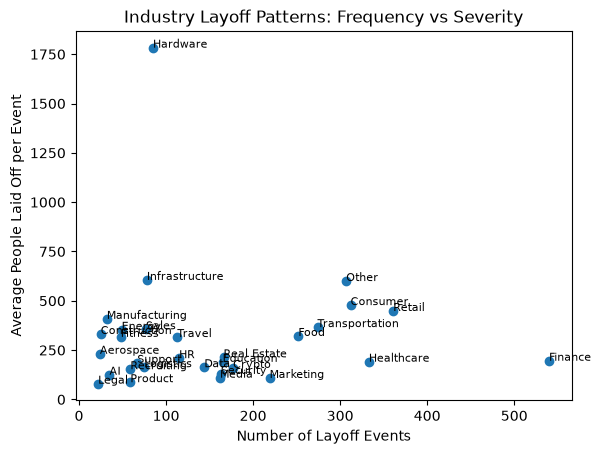

In [24]:
# scatter plot: does an industry lay off frequently but small, or rarely but severe
plt.scatter(industry_stats['event_count'], industry_stats['avg_size'])
for industry in industry_stats.index:
    plt.annotate(industry, (industry_stats.loc[industry, 'event_count'], industry_stats.loc[industry, 'avg_size']), fontsize=8)
plt.xlabel('Number of Layoff Events')
plt.ylabel('Average People Laid Off per Event')
plt.title('Industry Layoff Patterns: Frequency vs Severity')
plt.show()

In [25]:
stage_stats = df.groupby('stage').agg(
    event_count = ('company','count'),
    avg_size = ('total_laid_off','mean')
)
stage_stats

,event_count,avg_size
stage,,
Acquired,412,276.649254
Post-IPO,1091,753.143226
Private Equity,86,285.283019
Seed,152,57.312500
Series A,272,58.157233
Series B,491,104.696486
Series C,452,96.767361
Series D,363,108.894531
Series E,207,163.101911


- funding stage vs layoffs: Post-IPO companies lay off most often AND most severely,
- challenging the idea that mature/public companies are more stable

In [26]:
# disclosure rate by industry - which industries report actual layoff numbers most/least often
df.groupby('industry')['disclosed'].mean().sort_values(ascending=False)

industry
Sales             0.805195
Recruiting        0.745763
Manufacturing     0.718750
AI                0.714286
Security          0.699387
Hardware          0.694118
Support           0.686567
Media             0.685185
Travel            0.681416
Marketing         0.680365
HR                0.678261
Education         0.672727
Transportation    0.671533
Retail            0.667590
Logistics         0.666667
Fitness           0.666667
Finance           0.662963
Product           0.661017
Consumer          0.657051
Food              0.642857
Legal             0.636364
Healthcare        0.633634
Other             0.628664
Aerospace         0.625000
Data              0.611111
Real Estate       0.590361
Energy            0.571429
Crypto            0.559322
Infrastructure    0.525641
Construction      0.480000
Name: disclosed, dtype: float64

- insight: Sales, Recruiting, Manufacturing, AI disclose most often (>70%);
- Construction, Infrastructure, Crypto disclose least (<58%)

In [27]:
# top 10 companies by single largest layoff event
df.nlargest(10,'total_laid_off')[['company','industry','total_laid_off']]

,company,industry,total_laid_off
484,Intel,Hardware,22000.0
59,Oracle,Other,21000.0
246,Amazon,Retail,16000.0
802,Intel,Hardware,15000.0
321,Amazon,Retail,14000.0
968,Tesla,Transportation,14000.0
2440,Google,Consumer,12000.0
198,Dell,Hardware,11000.0
2925,Meta,Consumer,11000.0
2114,Meta,Consumer,10000.0


- Top 10 single largest layoff events: Intel (22,000 & 15,000 - two separate events),
  Oracle (21,000), Amazon (16,000 & 14,000 - two events), Tesla (14,000), Google (12,000),
  Dell (11,000), Meta (11,000 & 10,000 - two events)
- Confirms earlier Hardware/Consumer finding - Intel and Dell (Hardware) and Google/Meta
  (Consumer) directly account for the largest individual cuts
- Notable: several companies (Intel, Amazon, Meta) had MULTIPLE massive layoffs,
  not just one

In [28]:
# total layoffs by country
df.groupby('country')['total_laid_off'].sum().sort_values(ascending=False)

country
United States     657447.0
India              67509.0
Germany            32055.0
United Kingdom     24694.0
Netherlands        22175.0
                    ...   
Pakistan               0.0
Philippines            0.0
Peru                   0.0
South Africa           0.0
Vietnam                0.0
Name: total_laid_off, Length: 66, dtype: float64

In [29]:
# check event count vs total for these low/zero countries
df.groupby('country').agg(
    event_count=('company', 'count'),
    total_people=('total_laid_off', 'sum')
).sort_values('total_people', ascending=False)

,event_count,total_people
country,,
United States,2852,657447.0
India,348,67509.0
Germany,134,32055.0
United Kingdom,160,24694.0
Netherlands,31,22175.0
...,...,...
Pakistan,5,0.0
Philippines,1,0.0
Peru,1,0.0


Total layoffs by country - checked whether zero totals mean "no layoffs" or "undisclosed."
Found: US leads (657,447 total, 2,852 events), India second (67,509, 348 events).
Some countries (Pakistan, Philippines, Peru, South Africa, Vietnam) show 0 total despite
having real events - their layoffs were simply undisclosed, not actually zero. Power BI
map should account for this rather than showing these countries as unaffected.

In [30]:
india = df[df['country'] == 'India']

# total layoffs by city in India
india.groupby('location')['total_laid_off'].sum().sort_values(ascending=False)


location
Bengaluru      36735.0
Gurugram        8986.0
Mumbai          8182.0
Noida           5670.0
New Delhi       3862.0
Chennai         1425.0
Kochi            800.0
SF Bay Area      600.0
Ahmedabad        500.0
Hyderabad        500.0
Kolkata          125.0
Indore            75.0
Pune              30.0
Nashik            19.0
Jakarta            0.0
Patna              0.0
Trivandrum         0.0
Name: total_laid_off, dtype: float64

In [31]:
india.groupby('industry')['total_laid_off'].sum().sort_values(ascending=False)

industry
Education         14474.0
Finance            9941.0
Food               8187.0
Consumer           7348.0
Transportation     7170.0
Retail             7037.0
Healthcare         2857.0
Travel             2500.0
Other              1550.0
Fitness            1320.0
Media              1153.0
Logistics          1030.0
Marketing           718.0
Real Estate         600.0
Crypto              284.0
Support             257.0
AI                  230.0
Data                217.0
Recruiting          200.0
Construction        140.0
HR                  120.0
Sales               106.0
Energy               70.0
Manufacturing         0.0
Product               0.0
Name: total_laid_off, dtype: float64

- India industry breakdown: Education leads (14,474) - notably different from global
  pattern (Hardware/Retail dominate globally) - reflects India's edtech sector
  turbulence specifically
- India city breakdown (after fixing location labels): Bengaluru dominates
  (~36,735 combined), far ahead of Gurugram, Mumbai, Noida

In [32]:
df[df['company'] == 'Appgate']

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added,year,quarter,disclosed
2342,Appgate,Miami,34.0,2023-02-01,0.08,Security,https://seekingalpha.com/filing/7197018,Post-IPO,NaN,United States,2023-02-26,2023,1,True
